# 03-Transformations with dbt (Data Build Tool)

In Lesson 02, we engineered a Kimball Star Schema. We proved that by separating our data into a central `fact_sales` matrix and radially connected `dim_users` and `dim_products` matrices, we can achieve maximum query performance through vectorized database operations.

However, in a production enterprise environment, managing these tables by writing manual `CREATE TABLE AS SELECT` (CTAS) scripts in raw Python files creates an architectural nightmare:

1. **No Code Lineage**: If a query breaks, it is impossible to trace whether the failure originated in the raw source data or during a middle transformation step.
2. **State Management Redundancy**: Engineers must manually write boilerplate DDL (`DROP TABLE`, `ALTER TABLE`) to re-materialize data, wasting compute cycles and risking storage leaks.

To solve this, the modern data engineering ecosystem uses **dbt (Data Build Tool)**. dbt shifts the transformation layer completely into a software engineering discipline. We write clean, modular, version-controlled `SELECT` statements, and dbt's compilation engine automatically handles the complex dependency graph execution.

Let's set up our engine to study the compilation physics of dbt.

In [1]:
# Required installations: pip install duckdb pandas jinja2 matplotlib seaborn
import duckdb
import pandas as pd
from jinja2 import Template
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & dbt Transformation Engine Operational.")

✅ Systems Architecture & dbt Transformation Engine Operational.


# 1. The Physics of the dbt Compilation Graph

dbt operates on a beautifully simple premise: **Every model is a single `SELECT` statement saved in a `.sql` file.** There are absolutely no `CREATE` or `INSERT` statements allowed.

During execution, dbt acts as a compiler. It reads your raw SQL, parses your custom code dependencies, and wraps your queries in the appropriate database DDL based on your configuration parameters (e.g., `View`, `Table`, or `Incremental`).

### The Mathematical DAG ($\mathcal{G}$)

The core power of dbt lies in the `ref()` function. Instead of hardcoding physical database table names like `FROM production_db.silver_users`, you write `FROM {{ ref('silver_users') }}`.

This shifts the database from a collection of isolated tables into a strict **Directed Acyclic Graph (DAG)** $\mathcal{G} = (\mathcal{V}, \mathcal{E})$.

* $\mathcal{V}$ represents the SQL models (the compute nodes).
* $\mathcal{E}$ represents the directed edges created by the `ref()` statements.

The compiler runs a topological sort algorithm over $\mathcal{G}$ to determine the exact non-conflicting order of thread execution:


$$\text{Order} = \text{TopologicalSort}(\mathcal{G})$$

If Model C references Model B, and Model B references Model A, dbt guarantees that Model A is fully materialized before Model B's compilation pass begins. This completely prevents data race conditions.

# 2. Architecting the Live dbt Compilation Engine

Let's build a fully functioning, zero-abstraction dbt compilation runner using Python's `Jinja2` rendering engine and a physical **DuckDB** backend. We will write modular SQL models, resolve their dependencies via a custom rendering compiler, and materialize them into distinct database layers (**Bronze $\rightarrow$ Silver $\rightarrow$ Gold**).

In [2]:
# Initialize our physical analytical warehouse connection
conn = duckdb.connect('dbt_warehouse.db')

# --- 🪵 STEP 1: The Raw Ingestion Layer (Bronze) ---
conn.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
conn.execute("CREATE SCHEMA IF NOT EXISTS silver;")
conn.execute("CREATE SCHEMA IF NOT EXISTS gold;")

conn.execute("DROP TABLE IF EXISTS bronze.raw_events;")
conn.execute("""
    CREATE TABLE bronze.raw_events (
        event_id INT,
        user_id INT,
        payload VARCHAR,
        loaded_at TIMESTAMP
    );
""")
conn.execute("""
    INSERT INTO bronze.raw_events VALUES
    (101, 9942, '{"action": "login", "device": "mobile"}', '2026-06-24 10:00:00'),
    (102, 5511, '{"action": "purchase", "device": "desktop"}', '2026-06-24 10:05:00');
""")
print("--- 🪵 Bronze Layer Instantiated Natively ---")
print(conn.execute("SELECT * FROM bronze.raw_events").df().to_string())

--- 🪵 Bronze Layer Instantiated Natively ---
   event_id  user_id                                      payload           loaded_at
0       101     9942      {"action": "login", "device": "mobile"} 2026-06-24 10:00:00
1       102     5511  {"action": "purchase", "device": "desktop"} 2026-06-24 10:05:00


Now, let's architect our virtual dbt project folder repository containing our clean, declarative model files.

In [3]:
# --- 📁 STEP 2: The Virtual dbt Project Repository ---

# We store our modular dbt models as string templates, mimicking file storage
dbt_repository = {
    "stg_events.sql": {
        "materialized": "view",
        "sql": """
            SELECT 
                event_id,
                user_id,
                -- Native JSON extraction pushdown
                json_extract_string(payload, '$.action') AS event_action,
                json_extract_string(payload, '$.device') AS client_device,
                loaded_at
            FROM bronze.raw_events
        """
    },
    "fct_user_actions.sql": {
        "materialized": "table",
        "sql": """
            SELECT 
                event_id,
                user_id,
                event_action,
                loaded_at
            FROM {{ ref('stg_events') }} -- The magic dbt reference pointer!
            WHERE event_action IS NOT NULL
        """
    }
}


Now, let's write the physical execution compiler function. This script will replicate exactly what happens under the hood when you execute the terminal command `dbt run`.

In [4]:
# --- ⚙️ STEP 3: The dbt Compilation Pass ---

def dbt_compiler_run(model_name: str, repo: dict, db_connection) -> str:
    """Simulates the compilation and materialization mechanics of dbt."""
    model_meta = repo[f"{model_name}.sql"]
    raw_sql = model_meta["sql"]
    materialization = model_meta["materialized"]
    
    # Define our custom dbt Jinja context macros
    # The ref macro determines the correct target schema routing dynamically
    def ref(target_model_name: str) -> str:
        # In this pipeline architecture, views live in silver, tables in gold
        target_meta = repo[f"{target_model_name}.sql"]
        if target_meta["materialized"] == "view":
            return f"silver.{target_model_name}"
        return f"gold.{target_model_name}"
    
    # Compile the Jinja expressions down to raw SQL code
    template = Template(raw_sql)
    compiled_sql = template.render(ref=ref)
    
    # Determine the structural DDL wrapper wrapper based on configuration
    if materialization == "view":
        target_schema_table = f"silver.{model_name}"
        ddl_wrapper = f"CREATE OR REPLACE VIEW {target_schema_table} AS {compiled_sql};"
    elif materialization == "table":
        target_schema_table = f"gold.{model_name}"
        ddl_wrapper = f"CREATE OR REPLACE TABLE {target_schema_table} AS {compiled_sql};"
        
    print(f"\n🚀 [dbt COMPILER] Compiling model '{model_name}'...")
    print(f"   Wrapping as physical [{materialization.upper()}] DDL...")
    
    # Execute the final compiled string inside the database C++ engine
    db_connection.execute(ddl_wrapper)
    print(f"   ✅ Successfully materialized {target_schema_table}")
    
    return ddl_wrapper

# Execute the graph manually in its strict topological dependency order: Staging first, Fact second.
dbt_compiler_run("stg_events", dbt_repository, conn)
dbt_compiler_run("fct_user_actions", dbt_repository, conn)


🚀 [dbt COMPILER] Compiling model 'stg_events'...
   Wrapping as physical [VIEW] DDL...
   ✅ Successfully materialized silver.stg_events

🚀 [dbt COMPILER] Compiling model 'fct_user_actions'...
   Wrapping as physical [TABLE] DDL...
   ✅ Successfully materialized gold.fct_user_actions


'CREATE OR REPLACE TABLE gold.fct_user_actions AS \n            SELECT \n                event_id,\n                user_id,\n                event_action,\n                loaded_at\n            FROM silver.stg_events -- The magic dbt reference pointer!\n            WHERE event_action IS NOT NULL\n        ;'

# 3. Verifying the dbt Lineage Outputs

Let's read from the finalized tables to prove that our custom dbt compilation logic successfully passed state across schemas without any hardcoded database strings.

In [5]:
print("\n--- 🏁 Querying Final dbt Gold Layer Tables ---")

final_analytics_df = conn.execute("SELECT * FROM gold.fct_user_actions").df()
print("\n[gold.fct_user_actions Production State]:")
print(final_analytics_df.to_string())

print("\n--- 💡 Engineering Insight ---")
print("Analyze the compiled isolation abstraction. In our raw source files, we never wrote the words `CREATE TABLE` or `silver.stg_events`. We only wrote plain, declarative `SELECT` statements coupled with `{{ ref() }}` pointers.")
print("This architecture means your transformation code is entirely database-agnostic. If you migrate your platform tomorrow from DuckDB to Snowflake, you do not need to alter a single line of your SQL business logic. You simply change dbt's core connection profile config, and dbt will automatically adjust its compilation engine to generate Snowflake-compatible DDL on the fly.")


--- 🏁 Querying Final dbt Gold Layer Tables ---

[gold.fct_user_actions Production State]:
   event_id  user_id event_action           loaded_at
0       101     9942        login 2026-06-24 10:00:00
1       102     5511     purchase 2026-06-24 10:05:00

--- 💡 Engineering Insight ---
Analyze the compiled isolation abstraction. In our raw source files, we never wrote the words `CREATE TABLE` or `silver.stg_events`. We only wrote plain, declarative `SELECT` statements coupled with `{{ ref() }}` pointers.
This architecture means your transformation code is entirely database-agnostic. If you migrate your platform tomorrow from DuckDB to Snowflake, you do not need to alter a single line of your SQL business logic. You simply change dbt's core connection profile config, and dbt will automatically adjust its compilation engine to generate Snowflake-compatible DDL on the fly.


# 4. Visualizing the Compiled Pipeline Lineage Graph

To understand how dbt manages data flow securely across independent database schemas, let's plot the lineage graph of the compiled data assets.

/tmp/ipykernel_5931/1315116956.py:9: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  bronze_box = patches.Rectangle((0.5, 0.5), 3.0, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_5931/1315116956.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  silver_box = patches.Rectangle((4.5, 0.5), 3.0, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_5931/1315116956.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  gold_box = patches.Rectangle((8.5, 0.5), 3.0, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')


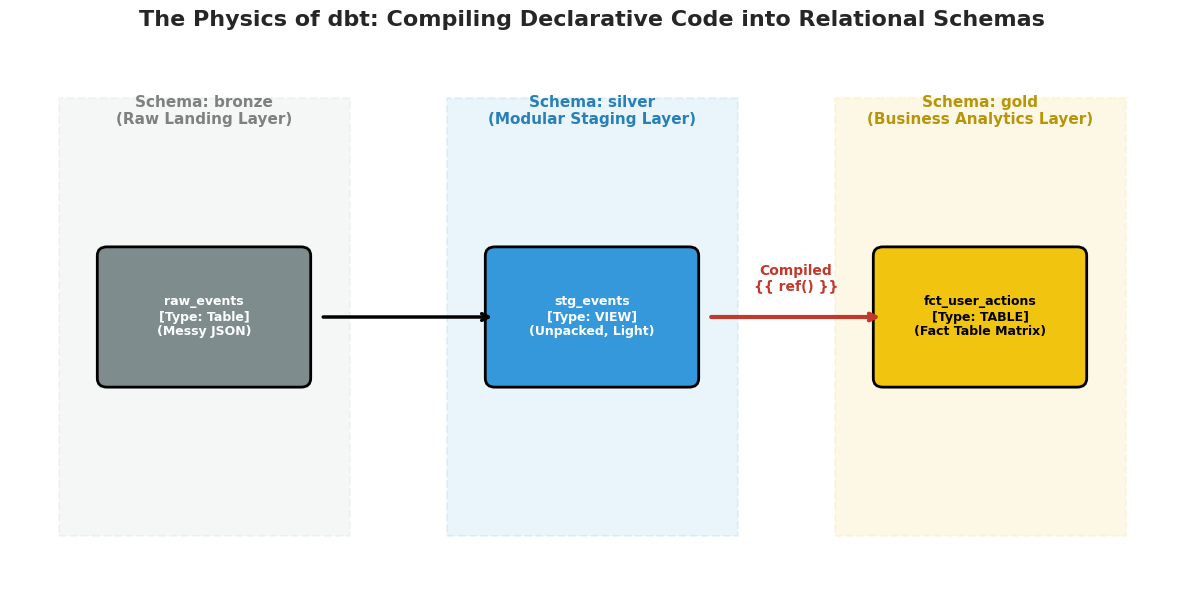

In [6]:
# Visualizing the dbt Lineage and Schema Topography
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("The Physics of dbt: Compiling Declarative Code into Relational Schemas", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Layer Boxes
# Bronze Schema
bronze_box = patches.Rectangle((0.5, 0.5), 3.0, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(bronze_box)
ax.text(2.0, 5.2, "Schema: bronze\n(Raw Landing Layer)", ha='center', color='gray', fontweight='bold', fontsize=11)

# Silver Schema
silver_box = patches.Rectangle((4.5, 0.5), 3.0, 5.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(silver_box)
ax.text(6.0, 5.2, "Schema: silver\n(Modular Staging Layer)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Gold Schema
gold_box = patches.Rectangle((8.5, 0.5), 3.0, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(gold_box)
ax.text(10.0, 5.2, "Schema: gold\n(Business Analytics Layer)", ha='center', color='#b7950b', fontweight='bold', fontsize=11)

# 2. Draw Tables
# bronze.raw_events
ax.add_patch(patches.FancyBboxPatch((1.0, 2.3), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#7f8c8d'))
ax.text(2.0, 3.0, "raw_events\n[Type: Table]\n(Messy JSON)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# silver.stg_events
ax.add_patch(patches.FancyBboxPatch((5.0, 2.3), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#3498db'))
ax.text(6.0, 3.0, "stg_events\n[Type: VIEW]\n(Unpacked, Light)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# gold.fct_user_actions
ax.add_patch(patches.FancyBboxPatch((9.0, 2.3), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(10.0, 3.0, "fct_user_actions\n[Type: TABLE]\n(Fact Table Matrix)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# 3. Draw Lineage Edges (The ref DAG)
# Bronze to Silver
ax.annotate("", xy=(5.0, 3.0), xytext=(3.2, 3.0), arrowprops=dict(arrowstyle="->", lw=2.5, color='black'))
# Silver to Gold via Jinja ref()
ax.annotate("", xy=(9.0, 3.0), xytext=(7.2, 3.0), arrowprops=dict(arrowstyle="->", lw=3, color='#c0392b', linestyle='solid'))
ax.text(8.1, 3.3, "Compiled\n{{ ref() }}", ha='center', fontweight='bold', color='#c0392b', fontsize=10)

plt.xlim(0, 12)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of managing database transformations with dbt like **Manufacturing an Automobile with Blueprint Modular Assemblies**:

* **Legacy Pipeline Engineering (The Custom Weld)**: Imagine building a car where every single component is welded directly to the next from scratch. If you decide to change the engine block from a V6 to an Electric Motor, you have to physically saw through the entire frame of the vehicle, rewrite the physical links to the exhaust pipes, and rebuild the dashboard interfaces by hand. This is the nightmare of hardcoded `INSERT INTO` warehouse scripts.
* **Modern dbt Pipeline Engineering (The Modular Assembly Line)**: You construct independent, standardized modular blueprints for each asset section.
* File 1 defines **The Engine Assembly Block (Staging View)**.
* File 2 defines **The Transmission Drive (Fact Table)**, and it includes a dynamic plug connector called `{{ ref('Engine') }}`.


* If you alter the internal design of the engine block, you do not touch the transmission block. You click a single button, and the automated factory assembly robot **(The dbt Compiler Engine)** automatically maps out the dependencies, verifies the attachment alignments, and snaps the modular components together inside the vehicle shell perfectly.